<a href="https://colab.research.google.com/github/chayan141/ML-DL-Projects/blob/main/ensemble_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bagging: Multiple instances of a base learners (e.g. decision trees) are trained on bootstrap samples of all features and then predictions are aggregated.

Each base models are trained on bootstrap samples, all features are considered for each model.

Randomforest: It is also a bagging method which selects random subset of features at each split in the decision trees. Used for classification, regression and feature importance.

Random forest takes random subsets of features per split.

Pasting : Similar to bagging but during tranining base models, instread of sampling with replacement, it samples without replacement, creating a subset of training data.

Data Preprocessing steps for RandomForest:

* Impute missing values (e.g., using mean, median, mode, or more advanced methods like KNN imputation).

* Categorical variables should be encoded to inumerical by using OHE, Ordinal Encoding.

* Randomforest or other decision tree based bagging methods are scale invariant, meaning they do not require feature scaling, this is because decision trees split based on feature threshold not destance or magniture.

* Outlier handling : Decison trees are relatively robust to outliers as they splits data based on feature thresholds, not distance metrices. However, extreme outliers can still affect split points and tree depth, potentially reducing performance.

* Randomforest inherently performs feature importance based on how much each features reduces impurity (Gini).

* Iandling Imbalanced Data : Randomforest or other bagging methods can struggle with imbalanced datasets as they have bias towards the majority class. Apply SMOTE or class_weights=balanced.

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

# Sample dataset
df = pd.DataFrame({"num_feature": [1, 2, None, 4], "cat_feature": ["A", "B", "A", "C"], "target": [0, 1, 0, 1]})

# Define preprocessing steps
numeric_features = ["num_feature"]
categorical_features = ["cat_feature"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", OneHotEncoder(), categorical_features),
    ]
)

# Create pipeline with Random Forest
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100))
])

# Split data
X = df.drop("target", axis=1)
y = df["target"]

# Fit model
pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['num_feature']),
                                                 ('cat', OneHotEncoder(),
                                                  ['cat_feature'])])),
                ('classifier', RandomForestClassifier())])

# Boosting Methods

Unlike bagging, which trains the models independently based on random subsets of features, boosting trains models sequentially, where each model focuses on correcting the mistakes made by the previous model by giving more weightage to the mistake. The final prediction is based on a weighted combination of weak learner's output.

Boosting reduces bias by iteratively improving the model's ability to fit the data, while also reducing variance to some extent.

Adaboost : Decision slumps (single level decision trees) are used. Assigns higher weights on misclassified points and subsequent weak learners also focus on them.

Final prediction made by combining all the weak learners using weighted voting for classification or averaging for regressions.

Gradient Boosting: Generalizes boosting by optimizes a loss function (e.g. MSE for regression or log-loss for classification) using gradient descent.

It also support huber loss:

Huber loss combines the properties of both MSE and MAE by using a quadratic function for small errors and linear functions for large errors. This loss used for regression tasks. It is robust to outliers.

XGBoost: An optimized version of gradient boosting which includes enhancements like regularization, parallelization, and handing missing values.

It adds L1 and L2 regularizations, Supports custom functions and evaluation metrices, handles missing value automatically by learning optimal splits, highly efficient for parallel processing and tree pruning.

LightGBM : It is useful for its speed and memoryefficiency, particularly for large datasets.

It uses histogram based learning and leaf wise tree growth.

Categorical Boosting : A gradient boosting algorithm designed to handle categorical features efficiently.

It automatically processes categorical features and reduces overfitting through ordered boosting.

It automatically encodes categorical variable using target encoding.

max_depth is used for pruning.

# XGBoost

XGBoost Hyperparameters :

learning_rate: Controls the contribution of each tree (e.g., 0.01, 0.1, 0.3).

n_estimators: Number of boosting rounds/trees (e.g., 50, 100, 200).

max_depth: Maximum depth of each tree (e.g., 3, 5, 7).
subsample: Fraction of training data sampled per tree (e.g., 0.6, 0.8, 1.0).

colsample_bytree: Fraction of features sampled per tree (e.g., 0.6, 0.8, 1.0).

gamma: Minimum loss reduction for a split (e.g., 0, 0.1, 0.2).

reg_alpha (L1 regularization) and reg_lambda (L2 regularization): Control model complexity (e.g., 0, 0.1, 1).

Use metrices f1, precision, recall or roc_auc for class imbalance instead of accuracy.

XGBoost supports early stopping to halt training whenever performance stops imporving.

for class imbalance use scale_pos_weight :

scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)

In [2]:
import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [3]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the XGBoost classifier
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)

In [4]:
# Define the parameter grid
param_grid = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'n_estimators': [50, 100, 200],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

In [5]:
# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',  # Metric for evaluation
    cv=2,                # 5-fold cross-validation
    n_jobs=-1,           # Use all available CPU cores
    verbose=1            # Print progress
)

In [6]:
# Fit GridSearchCV
grid_search.fit(X_train, y_train)

Fitting 2 folds for each of 243 candidates, totalling 486 fits


GridSearchCV(cv=2,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.3],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 200],
                         'subsample': [0.6, 0.8, 1.0]},
             scoring='accuracy', verbose=1)

In [7]:
# Print the best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.6}
Best Cross-Validation Accuracy: 0.9736165855166551


In [8]:
# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9561

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



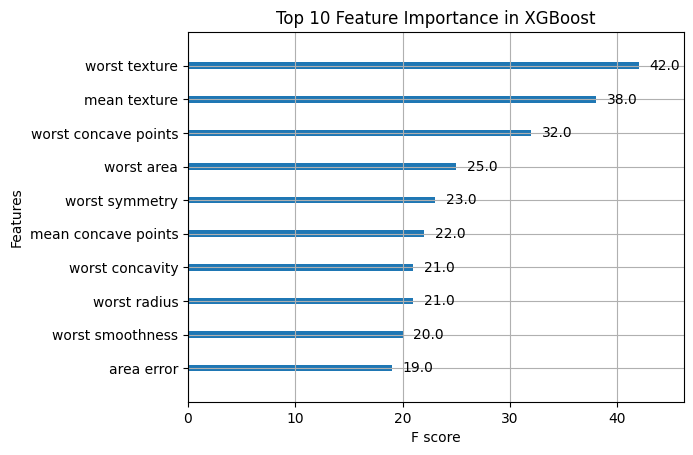

In [9]:
# Optional: Feature importance plot
import matplotlib.pyplot as plt
xgb.plot_importance(best_model, max_num_features=10)
plt.title("Top 10 Feature Importance in XGBoost")
plt.show()

# LightGBM

Used for large high dimensional datasets. It is computationally efficient for large datasets. It introduces faster training for large datasets.


* It introduces histogram based learning, It generally converts continuous features into discrete histogram bins, reducing memory usage and speeds up training.

* Natively handles categorical features without one hot encoding.

* Grows trees by splitting leafs.

* Supports L1 and L2 regularizations.

* Parallel processing supported and automatically handles missing values by placing them into optimal split direction.

learning_rate: Controls the contribution of each tree (e.g., 0.01–0.3).

num_leaves: Maximum number of leaves in each tree (e.g., 20–50); higher values increase complexity.

max_depth: Maximum tree depth to limit overfitting (e.g., 3–10).

n_estimators: Number of boosting rounds/trees (e.g., 50–500).

subsample: Fraction of data sampled per tree (e.g., 0.6–1.0).

colsample_bytree: Fraction of features sampled per tree (e.g., 0.6–1.0).

min_child_samples: Minimum number of samples per leaf (e.g., 10–100).

reg_alpha (L1 regularization) and reg_lambda (L2 regularization): Control model complexity.

In [10]:
import lightgbm as lgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# Define the LightGBM classifier
lgb_model = lgb.LGBMClassifier(objective='binary', metric='binary_logloss', random_state=42)

# Define the parameter grid for tuning
param_grid = {
    'learning_rate': [0.01, 0.1, 0.3],
    'num_leaves': [20, 31, 50],
    'max_depth': [3, 5, 7],
    'n_estimators': [50, 100, 200],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

In [13]:
# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid,
    scoring='accuracy',  # Metric for evaluation
    cv=2,                # 5-fold cross-validation
    n_jobs=-1,           # Use all available CPU cores
    verbose=1            # Print progress
)

In [14]:
# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Print the best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Fitting 2 folds for each of 729 candidates, totalling 1458 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 286, number of negative: 169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000167 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628571 -> initscore=0.526093
[LightGBM] [Info] Start training from score 0.526093
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

Test Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



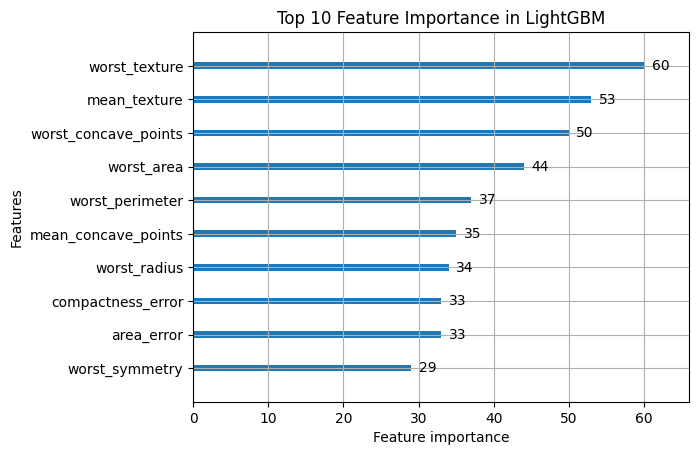

In [15]:
# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot feature importance
lgb.plot_importance(best_model, max_num_features=10)
plt.title("Top 10 Feature Importance in LightGBM")
plt.show()

Imbalanced Data: Use is_unbalance=True or scale_pos_weight for imbalanced datasets

Node  : Where splitting condition made.

Root Node : Staring Node of the tree.

leaf node: Ending node of the tree where final output is shown.


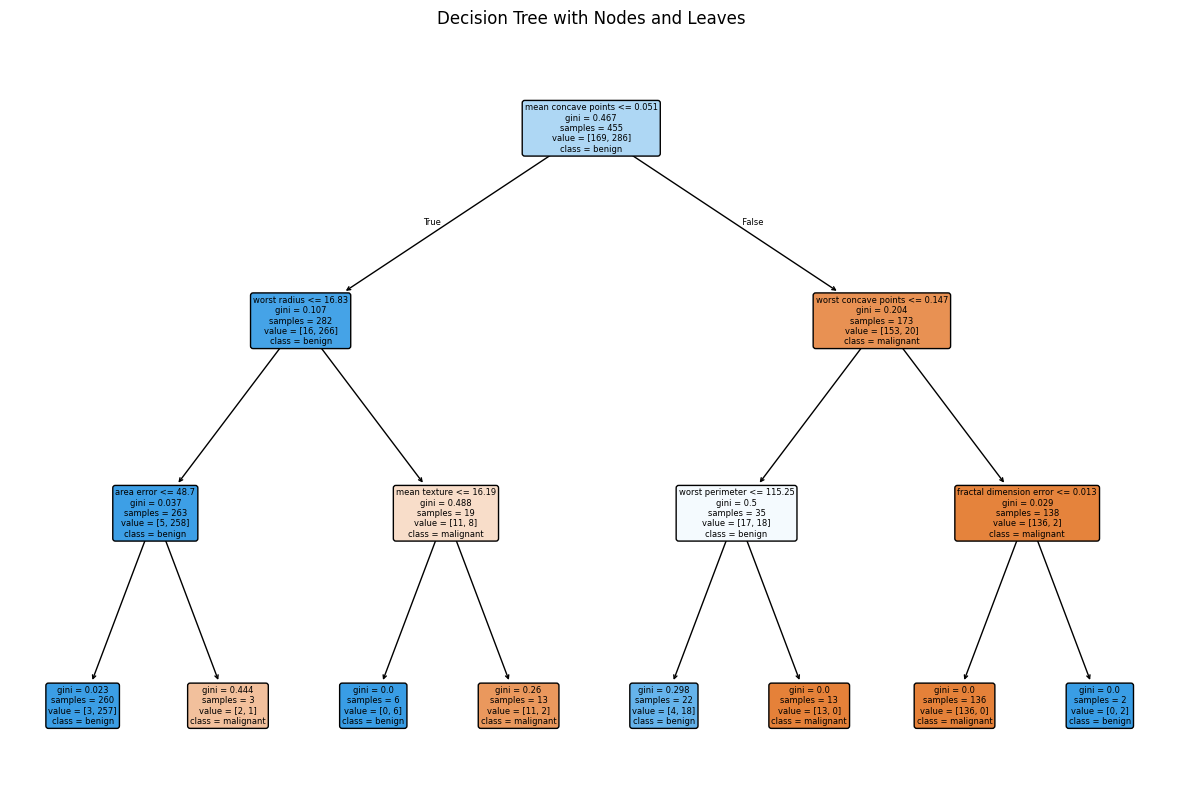

Number of Nodes: 15
Number of Leaves: 8


In [16]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a decision tree classifier
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# Visualize the decision tree
plt.figure(figsize=(15, 10))
tree.plot_tree(
    dt_model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True
)
plt.title("Decision Tree with Nodes and Leaves")
plt.show()

# Print tree details
print("Number of Nodes:", dt_model.tree_.node_count)
print("Number of Leaves:", dt_model.tree_.n_leaves)

# CatBoost

* Automatically handle categorical features by target encoding.

* reduces overfitting by using ordered boosting.

* XGB: Level wise tree growth, LGB: Leaf wise tree growth, Catboost: Symmetric Tree growth.

In [18]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.2 MB/s eta 0:00:00


In [19]:
import catboost as cb
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Load Iris dataset (3 classes)
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [20]:
# Simulate a categorical feature for demonstration
# Convert 'sepal length (cm)' into a categorical feature by binning
X['sepal_length_cat'] = pd.cut(X['sepal length (cm)'], bins=3, labels=['Low', 'Medium', 'High'])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define categorical feature indices
cat_features = ['sepal_length_cat']  # Specify categorical columns

In [21]:
# Define the CatBoost classifier
cb_model = cb.CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='MultiClass',
    cat_features=cat_features,
    random_seed=42,
    verbose=0  # Suppress training output
)

In [23]:
# Define parameter grid for tuning
param_grid = {
    'learning_rate': [0.01, 0.1],
    'depth': [4, 6],
    'iterations': [100, 200],
    'l2_leaf_reg': [1, 3]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=cb_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1)

In [24]:
# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Print the best parameters and score
print("\nCatBoost Results:")
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Fitting 5 folds for each of 16 candidates, totalling 80 fits

CatBoost Results:
Best Parameters: {'depth': 4, 'iterations': 100, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
Best Cross-Validation Accuracy: 0.95
Test Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



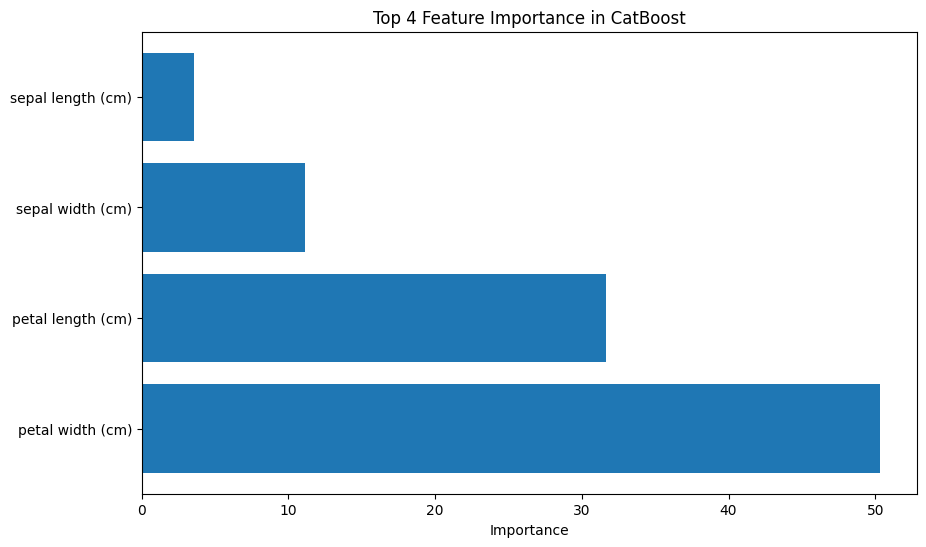

In [25]:
# Plot feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.get_feature_importance()
})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'][:4], feature_importance['Importance'][:4])
plt.title("Top 4 Feature Importance in CatBoost")
plt.xlabel("Importance")
plt.show()

Imbalanced Data: Use auto_class_weights='Balanced' for imbalanced datasets:

# Feature Selection Techniques

Selecting most informative features and discarding irrelevent or redundant features.

Filter Method : Select features based on statistical properties, independent of the machine learning model.

Wrapper Method : Use a specific ML model to evaluate subsets of features and selects the best performing features.

Embedded method : Perform feature selection as a part of model training, leveraging model's built in feature importance metrices.

# Filter Methods:

Uses statistical tests or measures.

Variance Threshold : Remove Features with low variance.

Correlation Based Selection : Removes highly correlated features to reduce redundancy.

Statistical Tests : Use metrices like ChiSquared or ANOVA to rank features based on their target relevence.

Mutual Information : Measures the mutual dependency between features and target.

In [26]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

# Load Iris dataset
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Variance Threshold
var_thresh = VarianceThreshold(threshold=0.1)  # Remove features with variance < 0.1
X_train_var = var_thresh.fit_transform(X_train)
X_test_var = var_thresh.transform(X_test)
selected_features_var = X.columns[var_thresh.get_support()].tolist()
print("Selected Features (Variance Threshold):", selected_features_var)

# 2. Mutual Information
mi_selector = SelectKBest(score_func=mutual_info_classif, k=2)  # Select top 2 features
X_train_mi = mi_selector.fit_transform(X_train, y_train)
X_test_mi = mi_selector.transform(X_test)
selected_features_mi = X.columns[mi_selector.get_support()].tolist()
print("Selected Features (Mutual Information):", selected_features_mi)

# Train CatBoost with selected features (Mutual Information)
cb_model = CatBoostClassifier(iterations=100, depth=4, learning_rate=0.1, verbose=0)
cb_model.fit(X_train_mi, y_train)
y_pred = cb_model.predict(X_test_mi)
print(f"Accuracy with Mutual Information Features: {accuracy_score(y_test, y_pred):.4f}")

Selected Features (Variance Threshold): ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Selected Features (Mutual Information): ['petal length (cm)', 'petal width (cm)']
Accuracy with Mutual Information Features: 1.0000


# Wrapper Method:

Selecting features by training a machine learning model n each subset of features and take best subset of features based on evaluation metrices.

RFE : Recursively removes less important features.

Forward Feature Selection : Starts with no features then iteratively add the features that improves performance.

Backword Elimination : Starts with all features and iteratively removes the least important one.

In [27]:
from sklearn.feature_selection import RFE
from catboost import CatBoostClassifier

# Define CatBoost classifier
cb_model = CatBoostClassifier(iterations=100, depth=4, learning_rate=0.1, verbose=0)

# Apply RFE to select top 2 features
rfe = RFE(estimator=cb_model, n_features_to_select=2)

rfe.fit(X_train, y_train)

selected_features_rfe = X.columns[rfe.support_].tolist()

print("Selected Features (RFE):", selected_features_rfe)

# Train and evaluate with selected features
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)
cb_model.fit(X_train_rfe, y_train)
y_pred = cb_model.predict(X_test_rfe)
print(f"Accuracy with RFE Features: {accuracy_score(y_test, y_pred):.4f}")

Selected Features (RFE): ['petal length (cm)', 'petal width (cm)']
Accuracy with RFE Features: 1.0000


Embedded Methods: Embedded methods perform feature selection as part of the model training process, leveraging the model’s built-in feature importance metrics.

Tree Based Feature Importance, L1 & L2 regularization,
permutation importance: measures the decrease in model's performance when a feature's value are randomly permuted, indicating its importance.

# Polynomial Regression